In [3]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
czi_name = "CB5-01_S1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [5]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

In [6]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [13]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    region= "full",
    pad_left_um=-1500.0,   # expand chip box leftward (µm)
    pad_right_um=-3000.0,  # expand chip box rightward (µm)
    pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um= 1300.0
)
    return roi

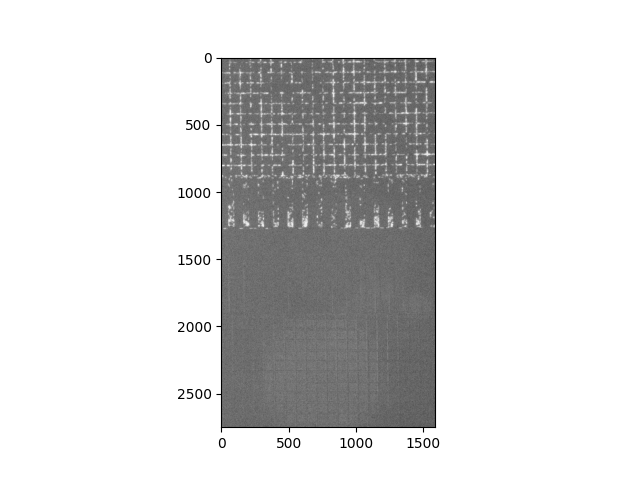

In [ ]:

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")


Gaussian BG sigma: 50.0 µm = 52.9 px


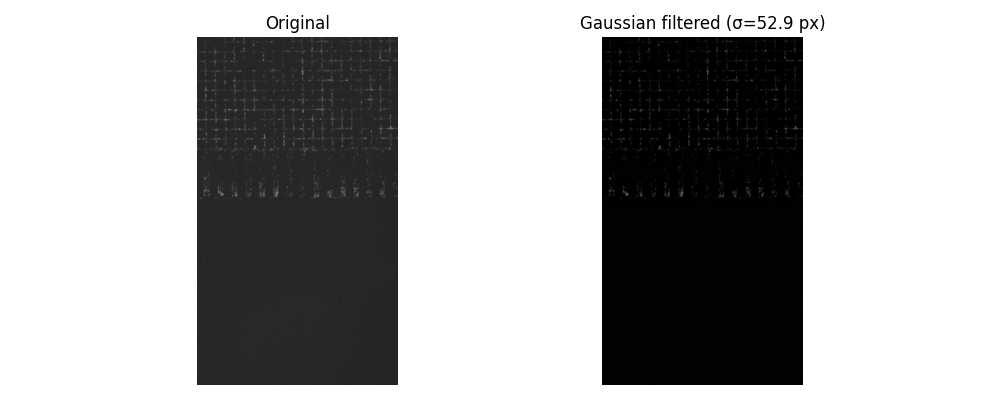

In [20]:
from scipy.ndimage import gaussian_filter
px_um = pixel_size["X"]

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

# ── Method 3: Gaussian background subtraction ─────────────────────────────────
# sigma >> cell size so background is smooth and cells are preserved
# Runtime: O(N log N) via FFT — independent of sigma
# Runtime: O(N log N) via FFT — independent of sigma
bg_sigma_um  = 50.0   # much larger than cell (~5 µm) → safe range: 10–50 µm
bg_sigma_px  = bg_sigma_um / pixel_size["X"]

background_gauss = gaussian_filter(img, sigma=bg_sigma_px)
img_gauss        = np.clip(img - background_gauss, 0, None)

print(f"Gaussian BG sigma: {bg_sigma_um} µm = {bg_sigma_px:.1f} px")
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(img_gauss, cmap="gray")
ax[1].set_title(f"Gaussian filtered (σ={bg_sigma_px:.1f} px)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Channel 1: 1365 cell(s) detected


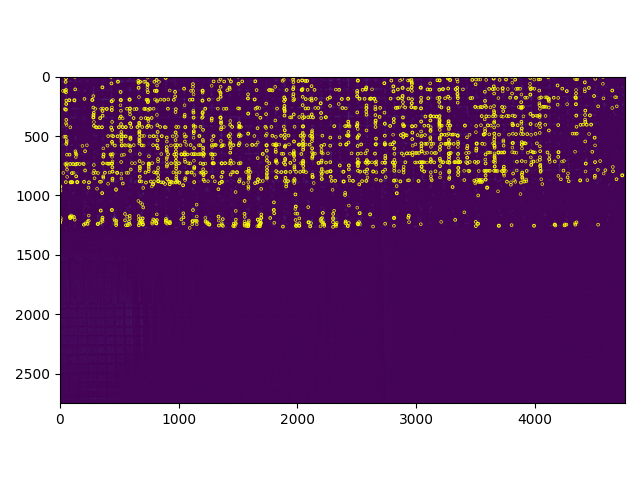

In [12]:
from chipanalysis.functions.region_fluorescence import count_cells
from skimage.feature import blob_doh, blob_log



# Count cells using calibrated function
n_cells = count_cells(img, channel, px_um=px_um)
print(f"Channel {channel}: {n_cells} cell(s) detected")

# For visualization, re-run blob detection with pixel-size-calibrated parameters
from skimage import exposure
p_low  = np.percentile(img_gauss, 0)      # dark background reference
p_high = np.percentile(img_gauss, 100)   # bright signal reference
img_norm = exposure.rescale_intensity(img_gauss, in_range=(p_low, p_high), out_range=(0, 1))
# img_norm = (img_norm - img_norm.mean()) / (img_norm.std() + 1e-8)

# Use calibrated parameters based on channel and pixel size
# Channel 0: ~1-2 µm cells → radius ~0.75 µm
cell_radius_um = 5
sigma_px = (cell_radius_um / px_um) / (2 ** 0.5)
min_sigma = max(1.0, sigma_px * 0.6)
max_sigma = max(2.0, sigma_px * 1.4)

blobs_doh = blob_log(img_norm, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=10, threshold=0.08)

blobs_list = [blobs_doh]
colors = ['yellow',]
titles = ['Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)
fig, ax = plt.subplots()

ax.imshow(img_gauss)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=2, fill=False)
    ax.add_patch(c)

plt.tight_layout()
plt.show()


In [16]:
# ── Install Cellpose (run once) ───────────────────────────────────────────────
# Cellpose is a deep-learning generalist cell segmentation model.
# Pre-trained models work out-of-the-box on fluorescence microscopy images.
#   pip install cellpose
import subprocess, importlib
if importlib.util.find_spec("cellpose") is None:
    subprocess.run(["pip", "install", "cellpose"], check=True)


  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 12.2 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 9.6 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 11.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.6/565.6 kB 11.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 12.2 MB/s  0:00:00eta 0:00:01
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 15.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [cellpose]/14 [torchvision]n-headless]



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
# ── Cellpose: load model ──────────────────────────────────────────────────────
# model_type choices:
#   'cyto3'   – cytoplasm/whole-cell (newest, most robust general model)
#   'cyto2'   – older cytoplasm model
#   'nuclei'  – if you stained the nucleus rather than the whole cell
#
# Set gpu=True if a CUDA-capable GPU is available for faster inference.
from cellpose import models

model_type = "cyto3"   # ← change to 'nuclei' for DAPI/Hoechst channels
# Cellpose 3.x uses CellposeModel (models.Cellpose was removed in v3)
model_cp = models.CellposeModel(gpu=False, model_type=model_type)
print(f"Cellpose model '{model_type}' loaded (CPU mode).")


model_type argument is not used in v4.0.1+. Ignoring this argument...
100%|██████████| 1.15G/1.15G [01:51<00:00, 11.0MB/s]


Cellpose model 'cyto3' loaded (CPU mode).


In [21]:
# ── Cellpose: run inference ───────────────────────────────────────────────────
# We use img_gauss (background-subtracted) to help the model focus on cells.
# Alternatively, pass the raw `img` and let Cellpose handle normalisation itself.
#
# Key parameters:
#   diameter  – estimated cell diameter in pixels; None = auto-estimate.
#               Setting it explicitly (from your known cell size) gives more
#               reliable results, especially for small or dense cells.
#   channels  – [cytoplasm_ch, nucleus_ch]; [0, 0] means single-channel greyscale.
#   flow_threshold    – (0–3) higher = keep more cells but more false positives.
#   cellprob_threshold – (-6 to 6) lower = more permissive cell detection.

cell_diameter_px = (cell_radius_um * 2) / px_um   # diameter in pixels

# Cellpose 3.x: eval() returns (masks, flows, styles) — no diams as 4th value
masks_cp, flows, styles = model_cp.eval(
    img_gauss,
    diameter=cell_diameter_px,
    channels=[0, 0],          # single-channel (greyscale) image
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    normalize=True,           # Cellpose internal normalisation
)

n_cells_cp = int(masks_cp.max())   # each unique label = one cell
print(f"Cellpose detected {n_cells_cp} cell(s)")


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


KeyboardInterrupt: 

In [ ]:
# ── Cellpose: visualise segmentation ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# (1) Background-subtracted input
axes[0].imshow(img_gauss, cmap="gray")
axes[0].set_title("Input (BG subtracted)")
axes[0].axis("off")

# (2) Cellpose instance masks (each cell gets a unique colour)
masked_overlay = np.ma.masked_where(masks_cp == 0, masks_cp)
axes[1].imshow(img_gauss, cmap="gray")
axes[1].imshow(masked_overlay, cmap="jet", alpha=0.5, interpolation="nearest")
axes[1].set_title(f"Cellpose masks  ({n_cells_cp} cells)")
axes[1].axis("off")

# (3) Side-by-side: LoG blobs (old) vs Cellpose count (new)
axes[2].imshow(img_gauss, cmap="gray")
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=1.5, fill=False)
    axes[2].add_patch(c)
axes[2].set_title(f"LoG blobs ({len(blobs_doh)} detected)  [old method]")
axes[2].axis("off")

plt.suptitle("Cell detection: Cellpose (ML) vs LoG (classical)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── StarDist (alternative – great for round/convex cells) ────────────────────
# StarDist represents each cell as a star-convex polygon, which is ideal for
# round cells like yeast, bacteria clusters, or cell nuclei.
#
# Install:  pip install stardist tensorflow   (or torch-based via stardist[tensorflow])
# Pre-trained models:
#   '2D_versatile_fluo'  – trained on diverse fluorescence images (best starting point)
#   '2D_paper_dsb2018'   – nuclei in DSB challenge images
#
# Uncomment and run after installing stardist:

# from stardist.models import StarDist2D
# from csbdeep.utils import normalize
#
# model_sd = StarDist2D.from_pretrained('2D_versatile_fluo')
#
# # StarDist expects float32 in [0, 1]
# img_sd = normalize(img_gauss.astype(np.float32), 1, 99.8)
#
# labels_sd, details_sd = model_sd.predict_instances(img_sd)
# n_cells_sd = int(labels_sd.max())
# print(f"StarDist detected {n_cells_sd} cell(s)")
#
# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
# axes[0].imshow(img_sd, cmap="gray");  axes[0].set_title("Input (normalised)");  axes[0].axis("off")
# masked_sd = np.ma.masked_where(labels_sd == 0, labels_sd)
# axes[1].imshow(img_sd, cmap="gray")
# axes[1].imshow(masked_sd, cmap="jet", alpha=0.5)
# axes[1].set_title(f"StarDist masks  ({n_cells_sd} cells)");  axes[1].axis("off")
# plt.tight_layout();  plt.show()
print("StarDist cell: uncomment the block above after running:  pip install stardist tensorflow")
